In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
data_dir = r"C:\Users\ADMIN\OneDrive\Documents\apple fruit disease\Apple Disease Dataset\Apple Disease Dataset\original split"

img_size = (224, 224)
batch_size = 32
seed = 42
num_classes = 5  


In [4]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, "train"),
    image_size=img_size,
    batch_size=batch_size,
    seed=seed,
    label_mode="int"
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, "val"),
    image_size=img_size,
    batch_size=batch_size,
    seed=seed,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, "test"),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    label_mode="int"
)

class_names = train_ds_raw.class_names
print("Class names:", class_names)


Found 2456 files belonging to 5 classes.
Found 524 files belonging to 5 classes.
Found 532 files belonging to 5 classes.
Class names: ['Anthracnose', 'Black Rot', 'Codling Moth', 'Healthy', 'Powdery Mildew']


In [18]:
y_train_all = []
for _, labels in train_ds_raw.unbatch():
    y_train_all.append(labels.numpy())

y_train_all = np.array(y_train_all)

class_weights_list = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_all),
    y=y_train_all
)

class_weights = {i: w for i, w in enumerate(class_weights_list)}
print("Class weights:", class_weights)


Class weights: {0: 2.046666666666667, 1: 1.038477801268499, 2: 3.6385185185185187, 3: 0.3948553054662379, 4: 1.3494505494505495}


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.shuffle(1000).cache().prefetch(AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


In [26]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
        layers.RandomBrightness(0.08),
        layers.RandomContrast(0.08),
    ],
    name="data_augmentation"
)


In [27]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=img_size + (3,)
)

base_model.trainable = False


9406464/9406464 [==============================] - 2s 0us/step


In [28]:
inputs = keras.Input(shape=img_size + (3,))

x = data_augmentation(inputs)  
x = tf.keras.applications.mobilenet_v2.preprocess_input(x) 
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                    

In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [30]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]


In [31]:
history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/10
77/77 [==============================] - 55s 668ms/step - loss: 1.8852 - accuracy: 0.2419 - val_loss: 1.4002 - val_accuracy: 0.4695
Epoch 2/10
77/77 [==============================] - 63s 813ms/step - loss: 1.4719 - accuracy: 0.4165 - val_loss: 1.1345 - val_accuracy: 0.6107
Epoch 3/10
77/77 [==============================] - 62s 804ms/step - loss: 1.1844 - accuracy: 0.5411 - val_loss: 0.9672 - val_accuracy: 0.6813
Epoch 4/10
77/77 [==============================] - 62s 809ms/step - loss: 1.0118 - accuracy: 0.6397 - val_loss: 0.8533 - val_accuracy: 0.7195
Epoch 5/10
77/77 [==============================] - 62s 811ms/step - loss: 0.8996 - accuracy: 0.6942 - val_loss: 0.7816 - val_accuracy: 0.7519
Epoch 6/10
77/77 [==============================] - 62s 807ms/step - loss: 0.8330 - accuracy: 0.7138 - val_loss: 0.7239 - val_accuracy: 0.7653
Epoch 7/10
77/77 [==============================] - 62s 804ms/step - loss: 0.7506 - accuracy: 0.7463 - val_loss: 0.6633 - val_accuracy: 0.7805

In [34]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.4)

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False


In [35]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),  
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [36]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
77/77 [==============================] - 105s 1s/step - loss: 0.5556 - accuracy: 0.8074 - val_loss: 0.3514 - val_accuracy: 0.8492
Epoch 2/20
77/77 [==============================] - 94s 1s/step - loss: 0.3841 - accuracy: 0.8660 - val_loss: 0.2979 - val_accuracy: 0.8760
Epoch 3/20
77/77 [==============================] - 96s 1s/step - loss: 0.3213 - accuracy: 0.8860 - val_loss: 0.2634 - val_accuracy: 0.8836
Epoch 4/20
77/77 [==============================] - 94s 1s/step - loss: 0.2833 - accuracy: 0.8921 - val_loss: 0.3296 - val_accuracy: 0.8607
Epoch 5/20
77/77 [==============================] - 94s 1s/step - loss: 0.2311 - accuracy: 0.9190 - val_loss: 0.2714 - val_accuracy: 0.8969
Epoch 6/20
77/77 [==============================] - 94s 1s/step - loss: 0.2149 - accuracy: 0.9198 - val_loss: 0.3025 - val_accuracy: 0.8855
Epoch 7/20
77/77 [==============================] - 94s 1s/step - loss: 0.1940 - accuracy: 0.9271 - val_loss: 0.2861 - val_accuracy: 0.8779
Epoch 8/20
77/77 [=

In [39]:
best_train_acc = max(history_finetune.history["accuracy"])
best_val_acc = max(history_finetune.history["val_accuracy"])

print(" Best Training Accuracy:", best_train_acc)
print(" Best Validation Accuracy:", best_val_acc)

 Best Training Accuracy: 0.9450325965881348
 Best Validation Accuracy: 0.8969465494155884


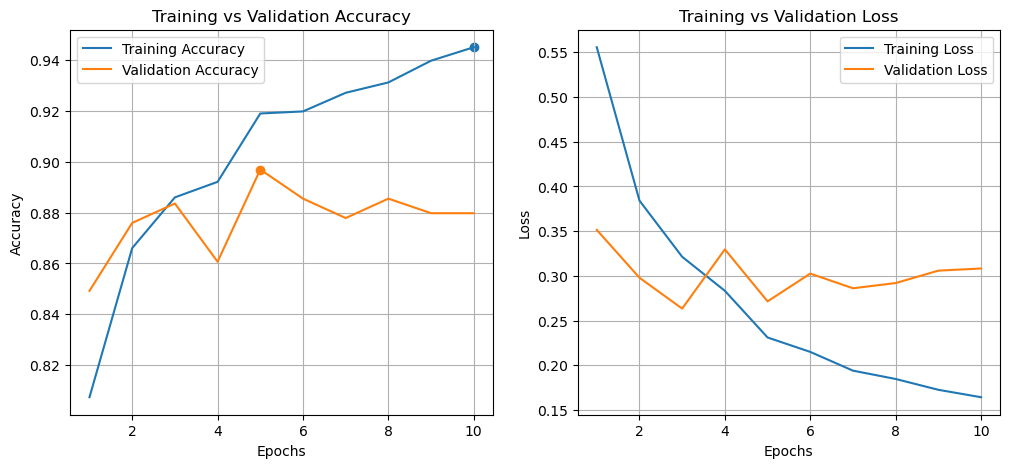

Best Training Accuracy: 0.9450325965881348
Best Validation Accuracy: 0.8969465494155884


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy values
train_acc = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']

# Loss values
train_loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']

epochs_range = range(1, len(train_acc) + 1)

# Find best values
best_train_acc = max(train_acc)
best_val_acc = max(val_acc)

# Create figure with 2 graphs
plt.figure(figsize=(12, 5))

# ------------------ Accuracy Graph ------------------
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.scatter(np.argmax(train_acc) + 1, best_train_acc)
plt.scatter(np.argmax(val_acc) + 1, best_val_acc)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# ------------------ Loss Graph ------------------
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

# Print best values
print("Best Training Accuracy:", best_train_acc)
print("Best Validation Accuracy:", best_val_acc)

In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, "test"),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    label_mode="int"
)

Found 532 files belonging to 5 classes.


In [6]:
test_loss, test_acc = model.evaluate(test_ds)
print("Final Test Accuracy:", test_acc)


17/17 [==============================] - 18s 870ms/step - loss: 0.1774 - accuracy: 0.9286
Final Test Accuracy: 0.9285714030265808


In [7]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


1/1 [==============================] - 2s 2s/step
Classification Report:
                precision    recall  f1-score   support

   Anthracnose       0.79      0.82      0.80        55
     Black Rot       0.89      0.86      0.88        95
  Codling Moth       0.93      0.80      0.86        35
       Healthy       0.96      0.99      0.97       268
Powdery Mildew       0.97      0.94      0.95        79

      accuracy                           0.93       532
     macro avg       0.91      0.88      0.89       532
  weighted avg       0.93      0.93      0.93       532

Confusion Matrix:
[[ 45   9   1   0   0]
 [ 12  82   0   1   0]
 [  0   1  28   6   0]
 [  0   0   1 265   2]
 [  0   0   0   5  74]]


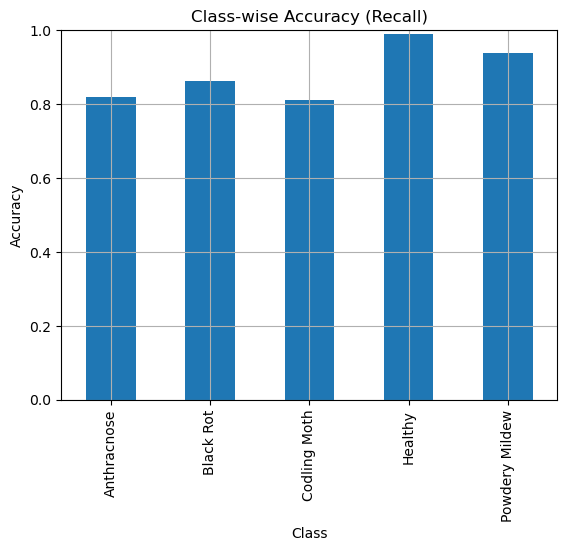

In [30]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df = pd.DataFrame(report).transpose()

plt.figure()
df['recall'][:-3].plot(kind='bar')
plt.title("Class-wise Accuracy (Recall)")
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

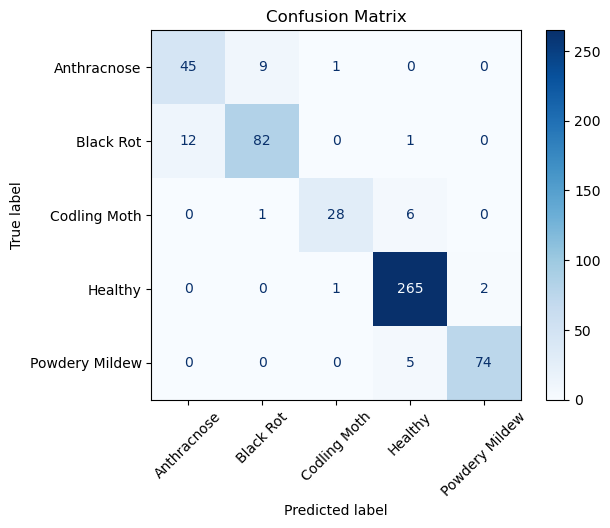

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
class_names = test_ds.class_names
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [10]:
model.save("apple_fruit_desease_mobnet.h5")

In [1]:
from tensorflow.keras.models import load_model

model = load_model("apple_fruit_desease_mobnet.h5")
print("Model loaded successfully!")

Model loaded successfully!
